### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
from torch.nn import LSTM
import lightgbm as lgbm
import catboost as cb


from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GroupKFold
from torch.utils.data import DataLoader, TensorDataset

### Read files & submission file for template

In [2]:
X_train = pd.read_csv('../data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('../data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('../data/y_train.csv',index_col='ROW_ID')
y_train_clf = pd.DataFrame((y_train['target']>0).astype(int))
sample_submission = pd.read_csv('../submissions/sample_submission.csv',index_col='ROW_ID')

In [3]:
X_train.head(5)

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


### Features

In [4]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [5]:
X_train.fillna(0)
X_test.fillna(0)

for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')

# Include the ALLOCATION feature as a categorical feature for the model (and hash it to integer to avoid issues with LightGBM)
hash_allocation = {v: i for i, v in enumerate(X_train['ALLOCATION'].unique())}

X_train['ALLOCATION'] = X_train['ALLOCATION'].map(hash_allocation)
X_test['ALLOCATION'] = X_test['ALLOCATION'].map(hash_allocation)

In [15]:
features = RET_features + SIGNED_VOLUME_features

### Fitting a catboost using cross validation

In [16]:
features_lgbm = features
print("Nombre de features: ", len(features))

Nombre de features:  40


In [17]:
train_dates = X_train['TS'].unique()
test_dates = X_test['TS'].unique()

n_splits = 8
scores = []
models = []

class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        logits = self.fc(out[:, -1, :]).squeeze(-1)
        return logits

splits = KFold(n_splits=n_splits, random_state=0, shuffle=True).split(train_dates)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids, features_lgbm].fillna(0).values.astype(np.float32)
    y_local_train = y_train_clf.loc[local_train_ids, 'target'].values.astype(np.float32)

    X_local_test = X_train.loc[local_test_ids, features_lgbm].fillna(0).values.astype(np.float32)
    y_local_test = y_train_clf.loc[local_test_ids, 'target'].values.astype(np.int64)

    X_local_train = X_local_train.reshape(X_local_train.shape[0], X_local_train.shape[1], 1)
    X_local_test = X_local_test.reshape(X_local_test.shape[0], X_local_test.shape[1], 1)

    train_dataset = TensorDataset(
        torch.from_numpy(X_local_train),
        torch.from_numpy(y_local_train),
    )
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)

    model = LSTMClassifier(input_size=1, hidden_size=16, num_layers=1).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 2
    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits_test = model(torch.from_numpy(X_local_test).to(device))
        proba_test = torch.sigmoid(logits_test).cpu().numpy()

    y_local_pred = (proba_test > 0.5).astype(int)

    models.append(model)
    score = accuracy_score(y_local_test, y_local_pred)
    scores.append(score)
    print(f"Fold {i+1} - Accuracy: {score * 100:.2f}%")

mean = np.mean(scores) * 100
std = np.std(scores) * 100

u = mean + std
l = mean - std

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')

Fold 1 - Accuracy: 50.98%
Fold 2 - Accuracy: 50.95%
Fold 3 - Accuracy: 51.53%
Fold 4 - Accuracy: 50.67%
Fold 5 - Accuracy: 50.57%
Fold 6 - Accuracy: 50.67%


KeyboardInterrupt: 

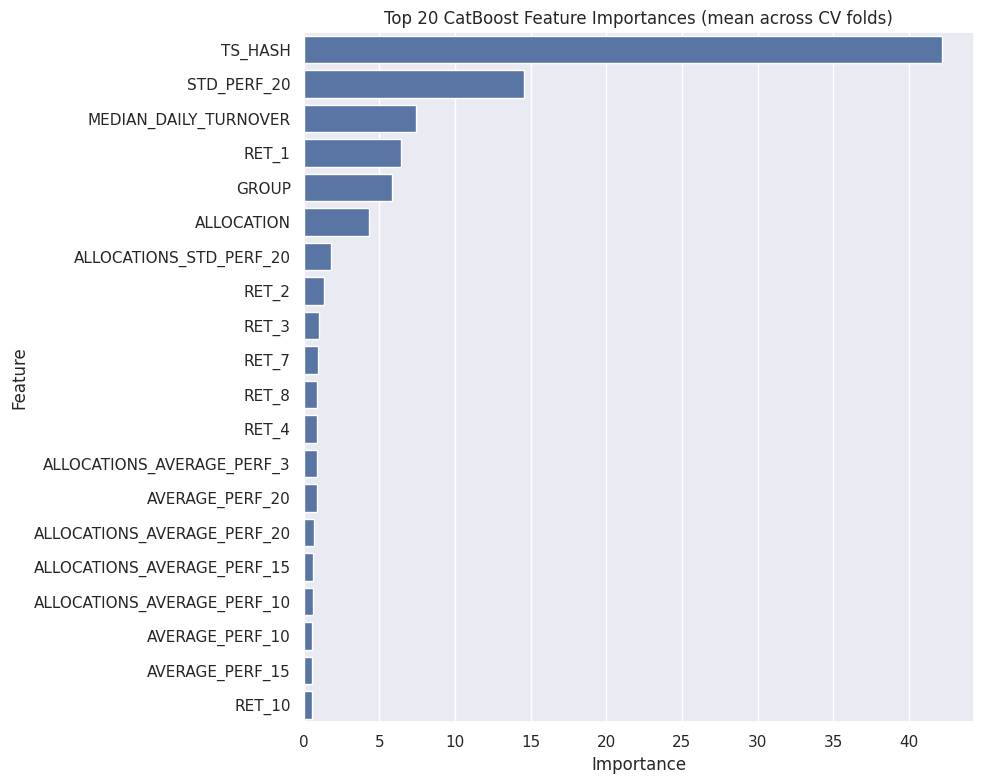

In [ ]:
feature_importances = pd.DataFrame(
	[model_cb.get_feature_importance(type='FeatureImportance') for model_cb in models_cb],
	columns=features_lgbm
)

top_features = feature_importances.mean(0).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, orient='h')
plt.title('Top 20 CatBoost Feature Importances (mean across CV folds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
